# Anomaly Detection & Time Series

### Question 1: What is Anomaly Detection? Explain its types (point, contextual, and collective anomalies) with examples. 

--> Anomaly Detection is the process of identifying rare or unusual patterns in a dataset that do not conform to expected behavior. These unusual observations are known as anomalies or outliers and may indicate critical incidents such as fraud, faults, or system failures.

1. Point Anomaly

A point anomaly occurs when a single data instance significantly deviates from the rest of the data.

>Example:
In credit card transactions, a purchase of ₹1,00,000 made suddenly from a normally low-spending account can be considered a point anomaly.

2. Contextual Anomaly

A contextual anomaly occurs when a data instance is abnormal in a specific context but may be normal in another.

>Example:
A temperature of 30°C is normal during summer but would be considered anomalous during winter.

3. Collective Anomaly

A collective anomaly occurs when a group of related data points deviates from the expected pattern, even if individual points may appear normal.

>Example:
In ECG readings, a sequence of slightly irregular heartbeats may collectively indicate a health issue.

### Question 2: Compare Isolation Forest, DBSCAN, and Local Outlier Factor in terms of their approach and suitable use cases.

| Method                     | Approach                                                                   | Suitable Use Case                                 |
| -------------------------- | -------------------------------------------------------------------------- | ------------------------------------------------- |
| Isolation Forest           | Detects anomalies by isolating observations using random decision trees    | High-dimensional datasets such as fraud detection |
| DBSCAN                     | Density-based clustering method that marks low-density points as anomalies | Spatial datasets such as GPS tracking             |
| Local Outlier Factor (LOF) | Measures deviation of density of a point compared to its neighbors         | Detecting local anomalies in complex datasets     |


Isolation Forest works efficiently with large datasets, DBSCAN is effective in detecting arbitrarily shaped clusters, and LOF is useful when anomalies are locally defined rather than globally.

### Question 3: What are the key components of a Time Series? Explain each with one example.

1. Trend

Represents the long-term increase or decrease in the data.

>Example:
Increase in airline passengers over years.

2. Seasonality

Represents repeating short-term patterns in the data.

>Example:
Higher electricity usage during summer months.

3. Cyclical Variation

Represents fluctuations over longer time periods due to economic conditions.

>Example:
Business cycles in stock market data.

4. Irregular Component

Represents random variations or noise.

>Example:
Sudden spike in sales due to an unexpected event.

### Question 4: Define Stationary in time series. How can you test and transform a non-stationary series into a stationary one?

A time series is said to be stationary when its statistical properties such as mean, variance, and autocorrelation remain constant over time.

Testing Stationarity

Stationarity can be tested using:

Augmented Dickey-Fuller (ADF) Test

KPSS Test

If the p-value in ADF test is less than 0.05, the series is considered stationary.

Transforming Non-Stationary to Stationary

1. Differencing

2. Log Transformation

3. Moving Average Smoothing

4. Seasonal Differencing

These techniques help remove trend and seasonality from the series.

### Question 5: Differentiate between AR, MA, ARIMA, SARIMA, and SARIMAX models in terms of structure and application.

| Model   | Structure                       | Application                          |
| ------- | ------------------------------- | ------------------------------------ |
| AR      | Depends on past values          | Short-term forecasting               |
| MA      | Depends on past errors          | Noise smoothing                      |
| ARIMA   | Combines AR + I + MA            | Non-seasonal time series forecasting |
| SARIMA  | ARIMA with seasonal component   | Seasonal data forecasting            |
| SARIMAX | SARIMA with exogenous variables | Forecasting with external factors    |


### Question 6: Load a time series dataset (e.g., AirPassengers), plot the original series, and decompose it into trend, seasonality, and residual components

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

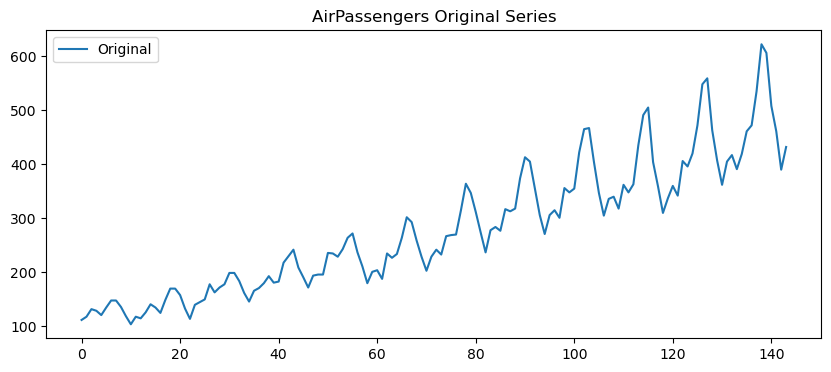

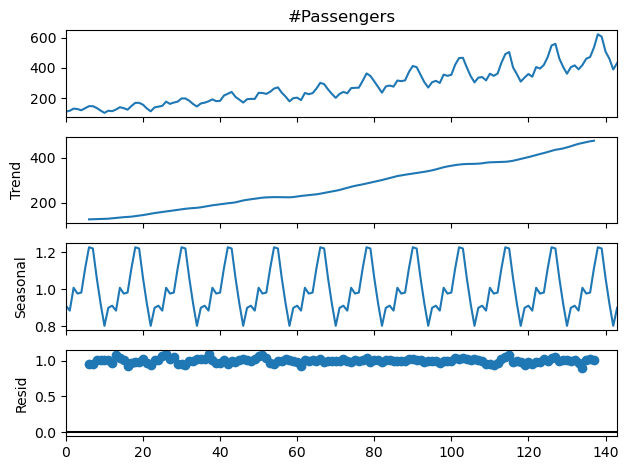

In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose

# my way to import directly from google drive
# https://drive.google.com/file/d/1eu6DQtqaH2qmJZU_RU5tQe5hhYejjXW3/view?usp=sharing
# changed to https://drive.google.com/uc?id=1eu6DQtqaH2qmJZU_RU5tQe5hhYejjXW3g

data_air = pd.read_csv('https://drive.google.com/uc?id=1eu6DQtqaH2qmJZU_RU5tQe5hhYejjXW3')

plt.figure(figsize=(10,4))
plt.plot(data_air['#Passengers'], label='Original')
plt.title('AirPassengers Original Series')
plt.legend()
plt.show()

decompose = seasonal_decompose(data_air['#Passengers'], model='multiplicative', period=12)

decompose.plot()
plt.show()

### Question 7: Apply Isolation Forest on a numerical dataset (e.g., NYC Taxi Fare) to detect anomalies. Visualize the anomalies on a 2D scatter plot.

In [1]:
### On google colab

### Question 8: Train a SARIMA model on the monthly airline passengers dataset. Forecast the next 12 months and visualize the results.

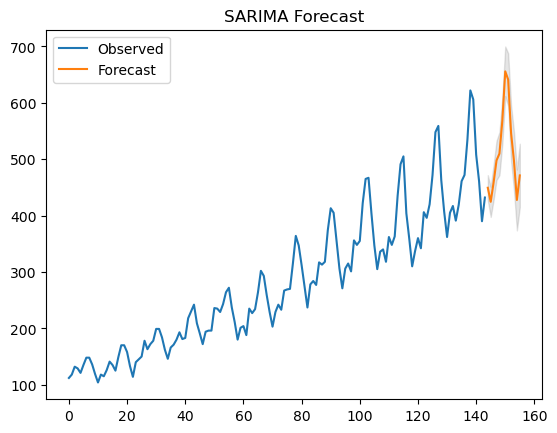

In [13]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(data_air['#Passengers'], order=(1,1,1), seasonal_order=(1,1,1,12))
results = model.fit()

forecast = results.get_forecast(steps=12)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

plt.plot(data_air['#Passengers'], label='Observed')
plt.plot(forecast_mean, label='Forecast')
plt.fill_between(forecast_ci.index, forecast_ci.iloc[:,0], forecast_ci.iloc[:,1], color='k', alpha=0.1)
plt.title('SARIMA Forecast')
plt.legend()
plt.show()

### Question 9: Apply Local Outlier Factor (LOF) on any numerical dataset to detect anomalies and visualize them using matplotlib.

In [2]:
### On google colab

### Question 10: You are working as a data scientist for a power grid monitoring company. Your goal is to forecast energy demand and also detect abnormal spikes or drops in real-time consumption data collected every 15 minutes. The dataset includes features like timestamp, region, weather conditions, and energy usage. Explain your real-time data science workflow:
>● How would you detect anomalies in this streaming data (Isolation Forest / LOF /
DBSCAN)?

>● Which time series model would you use for short-term forecasting (ARIMA /
SARIMA / SARIMAX)?

>● How would you validate and monitor the performance over time?

>● How would this solution help business decisions or operations?

Anomaly Detection

Isolation Forest can be used on streaming data to detect abnormal spikes in energy usage every 15 minutes.

Forecasting Model

SARIMAX model is suitable as it considers external variables like weather and region.

Validation & Monitoring

Use RMSE and MAE

Rolling window validation

Monitor prediction errors in real time

Business Impact

Prevent grid failures

Optimize energy distribution

Improve demand planning

Reduce operational cost